In [1]:
import os
os.chdir("..")   # only if the notebook starts inside notebooks/

import duckdb
import pandas as pd
import matplotlib.pyplot as plt

con = duckdb.connect("data/clickstream.duckdb")

In [2]:
con.sql("""
SELECT
    COUNT(*) FILTER (
        WHERE first_purchase IS NOT NULL
    ) AS purchase_sessions,

    COUNT(*) FILTER (
        WHERE first_purchase IS NOT NULL
          AND first_cart IS NULL
    ) AS purchase_no_cart,

    COUNT(*) FILTER (
        WHERE first_purchase IS NOT NULL
          AND first_view IS NULL
    ) AS purchase_no_view,

    COUNT(*) FILTER (
        WHERE first_purchase IS NOT NULL
          AND first_cart > first_purchase
    ) AS cart_after_purchase,

    COUNT(*) FILTER (
        WHERE first_cart IS NOT NULL
          AND first_view IS NULL
    ) AS cart_no_view

FROM session_stages
""").df()

,purchase_sessions,purchase_no_cart,purchase_no_view,cart_after_purchase,cart_no_view
0,259221,83720,926,4734,1174


In [3]:
funnel = con.sql("""
SELECT *
FROM mart_funnel_overall
ORDER BY funnel_type, step
""").df()

funnel

,funnel_type,step,stage,n_sessions,step_conv_pct,cum_conv_pct
0,loose,1,view,3739988,NaN,100.00
1,loose,2,cart,408466,10.92,10.92
2,loose,3,purchase,259221,63.46,6.93
3,strict,1,view,3739988,NaN,100.00
4,strict,2,cart,404849,10.82,10.82
5,strict,3,purchase,169382,41.84,4.53


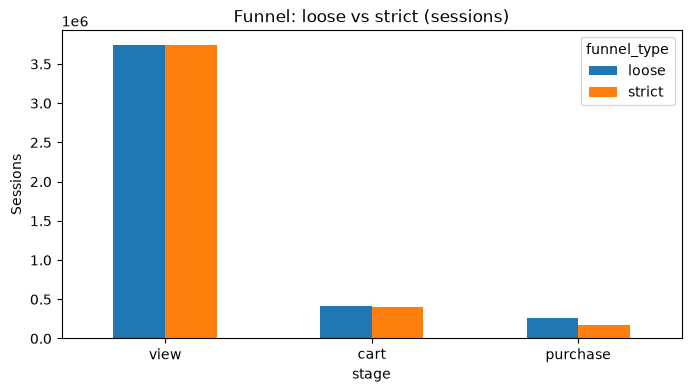

In [5]:
piv = funnel.pivot(
    index="stage",
    columns="funnel_type",
    values="n_sessions"
).loc[["view", "cart", "purchase"]]

piv.plot(
    kind="bar",
    figsize=(8, 4),
    title="Funnel: loose vs strict (sessions)"
)

plt.ylabel("Sessions")
plt.xticks(rotation=0)
plt.show()

In [6]:
cat = con.sql("""
    SELECT *
    FROM mart_funnel_category
    WHERE view_sessions >= 1000
      AND category_l1 <> 'unknown'
    ORDER BY view_to_purchase_pct
""").df()

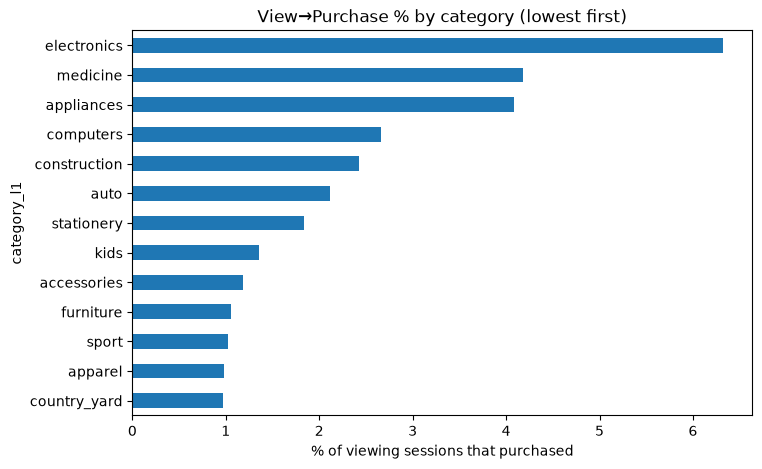

In [7]:
cat.plot(
    kind="barh",
    x="category_l1",
    y="view_to_purchase_pct",
    legend=False,
    figsize=(8, 5),
    title="View→Purchase % by category (lowest first)"
)

plt.xlabel("% of viewing sessions that purchased")
plt.show()

In [8]:
cat["lost_sessions"] = (
    cat["view_sessions"] - cat["purchase_sessions"]
)

top_dropoffs = cat.sort_values(
    "view_to_purchase_pct"
).head(3)[
    [
        "category_l1",
        "view_sessions",
        "view_to_purchase_pct",
        "lost_sessions"
    ]
]

top_dropoffs

,category_l1,view_sessions,view_to_purchase_pct,lost_sessions
0,country_yard,2072.0,0.97,2052.0
1,apparel,196336.0,0.98,194407.0
2,sport,23416.0,1.02,23177.0


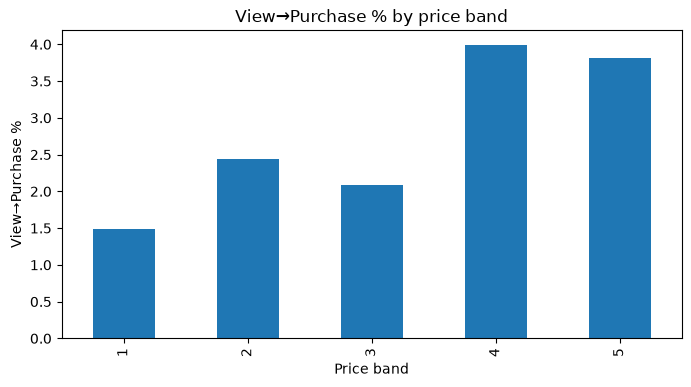

In [10]:
priceband = con.sql("""
    SELECT *
    FROM mart_funnel_priceband
    ORDER BY price_band
""").df()

priceband.plot(
    kind="bar",
    x="price_band",
    y="view_to_purchase_pct",
    legend=False,
    figsize=(8, 4),
    title="View→Purchase % by price band"
)

plt.xlabel("Price band")
plt.ylabel("View→Purchase %")
plt.show()

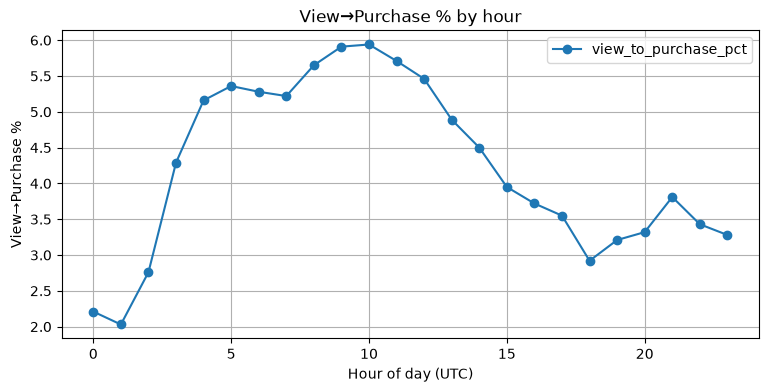

In [11]:
hour = con.sql("""
    SELECT *
    FROM mart_funnel_hour
    ORDER BY hour_of_day
""").df()

hour.plot(
    kind="line",
    x="hour_of_day",
    y="view_to_purchase_pct",
    marker="o",
    figsize=(9, 4),
    title="View→Purchase % by hour"
)

plt.xlabel("Hour of day (UTC)")
plt.ylabel("View→Purchase %")
plt.grid(True)
plt.show()

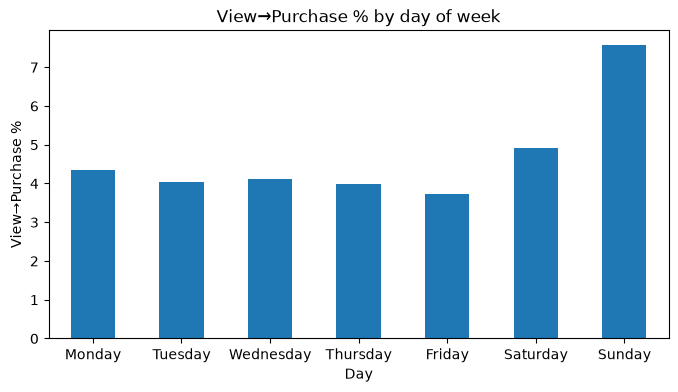

In [12]:
dow = con.sql("""
    SELECT *
    FROM mart_funnel_dow
    ORDER BY dow_num
""").df()

dow.plot(
    kind="bar",
    x="day_name",
    y="view_to_purchase_pct",
    legend=False,
    figsize=(8, 4),
    title="View→Purchase % by day of week"
)

plt.xlabel("Day")
plt.ylabel("View→Purchase %")
plt.xticks(rotation=0)
plt.show()

In [13]:
strict = con.sql("""
    SELECT *
    FROM mart_funnel_overall
    WHERE funnel_type = 'strict'
    ORDER BY step
""").df()

assert strict["n_sessions"].is_monotonic_decreasing, \
    "Strict funnel goes UP, check the SQL!"

print("Strict funnel is monotonic.")

Strict funnel is monotonic.


In [14]:
for t in [
    "mart_funnel_category",
    "mart_funnel_brand",
    "mart_funnel_priceband"
]:
    d = con.sql(f"""
        SELECT *
        FROM {t}
    """).df()

    assert (
        (d.view_sessions >= d.cart_sessions).all()
        and
        (d.cart_sessions >= d.purchase_sessions).all()
    ), t

print("All funnels are monotonic")

All funnels are monotonic


In [15]:
con.sql("""
    SELECT *
    FROM mart_session_diagnostics
""").df()

,n_sessions,bounce_pct,avg_events_per_session,median_events_per_session,avg_min_to_first_cart,median_min_to_first_cart
0,3741708,29.54,5.84,3.0,6.05,1.55


In [ ]:
cat["lost_sessions"] = (
    cat["view_sessions"] - cat["purchase_sessions"]
)

top_dropoffs = cat.sort_values(
    "view_to_purchase_pct"Z
).head(3)[
    [
        "category_l1",
        "view_sessions",
        "view_to_purchase_pct",
        "lost_sessions"
    ]
]

top_dropoffs

,category_l1,view_sessions,view_to_purchase_pct,lost_sessions
0,country_yard,2072.0,0.97,2052.0
1,apparel,196336.0,0.98,194407.0
2,sport,23416.0,1.02,23177.0
